# 1. Importando bibliotecas

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV

from sklearn.pipeline import Pipeline

import sys

import joblib

# 2. Clonando el repositorio

In [2]:
!git clone -b feature/model-training https://github.com/ezeperezds/Anemia-Prediction-System.git

Cloning into 'Anemia-Prediction-System'...
remote: Enumerating objects: 97, done.
remote: Counting objects: 100% (97/97), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 97 (delta 31), reused 73 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (97/97), 2.29 MiB | 3.58 MiB/s, done.
Resolving deltas: 100% (31/31), done.


In [3]:
sys.path.append('/content/Anemia-Prediction-System/')

# 3. Importando los datos

In [4]:
X_temp = pd.read_csv('/content/Anemia-Prediction-System/data/processed/X_temp.csv')
X_train = np.load('/content/Anemia-Prediction-System/data/processed/X_train.npy')
X_val = np.load('/content/Anemia-Prediction-System/data/processed/X_val.npy')

y_temp = np.load('/content/Anemia-Prediction-System/data/processed/y_temp.npy')
y_train = np.load('/content/Anemia-Prediction-System/data/processed/y_train.npy')
y_val = np.load('/content/Anemia-Prediction-System/data/processed/y_val.npy')

In [5]:
from src.preprocessing.features import FeatureSelector

In [6]:
preprocessor = joblib.load('/content/Anemia-Prediction-System/models/preprocessor_pipeline.pkl')

In [7]:
X_train.shape

(993, 8)

In [8]:
X_val.shape

(214, 8)

# 4. Definiendo la métrica del problema

**Desglosar**


Metrica/s a utilizar -> Recall por el peso que tienen los falsos negativos, F1-Score para mantener balance entre precision y recall

# 5. Modelos candidatos a evaluar

**Desglosar**

Posibles candidatos:

* LogisticRegression(Baseline) ✅
* XGBoost
* LightGBM
* SVC
* DecisionTree
* RandomForest
* CatBoost

In [9]:
def show_metrics(model_name, y_true, y_pred):
  metrics = {
      'accuracy': round(accuracy_score(y_true, y_pred), 2),
      'precision': round(precision_score(y_true, y_pred), 2),
      'recall': round(recall_score(y_true, y_pred), 2),
      'f1-score': round(f1_score(y_true, y_pred), 2)
  }

  return f'{model_name} metrics: {metrics}'

In [10]:
def show_confusion_matrix(y_true, y_pred):
  matrix = confusion_matrix(y_true, y_pred)
  visualizer = ConfusionMatrixDisplay(matrix, display_labels=['Sin anemia', 'Con anemia'])
  return visualizer.plot()

In [11]:
def show_cv_metrics(model_scores):
  metrics = {
    "accuracy":
        model_scores["test_accuracy"].mean().round(4),

    "precision":
        model_scores["test_precision"].mean().round(4),

    "recall":
        model_scores["test_recall"].mean().round(4),

    "f1":
        model_scores["test_f1"].mean().round(4)
        }
  return metrics

# 6. Modelado

## 1. Baseline

In [12]:
baseline_model = LogisticRegression(random_state=82, max_iter=1000, C=0.01)

baseline_model.fit(X_train, y_train)

LogisticRegression(C=0.01, max_iter=1000, random_state=82)

In [13]:
y_pred_baseline = baseline_model.predict(X_val)

### 1.1 Evaluación de metricas

In [14]:
log_metrics = show_metrics('logistic regresion', y_val, y_pred_baseline)
log_metrics

"logistic regresion metrics: {'accuracy': 0.92, 'precision': 0.9, 'recall': 0.92, 'f1-score': 0.91}"

La evaluación del modelo de regresión logistica realizada sobre el conjunto de validación retorno las siguientes métricas:

---

| Métrica   | Valor   | Interpretación       |
|---------- |------   |--------------|
| Accuracy  | 0.92    | El modelo clasifico correctamente el 92% de las muestras.       |
| Precision | 0.9    | De todas las predicciones positivas, el 90% corresponden realmente a casos positivos. |
| Recall    | 0.92    | El modelo clasifico correctamente el 92% de casos positivos del conjunto de datos.       |
| F1-Score  | 0.91    | El balance entre precisión y recall fue de un 91%, indicando un buen desempeño general considerando ambas métricas.       |


---

#### **Análisis**

El modelo obtuvo un recall del 92%, es decir, fue capaz de detectar correctamente el 92% de datos pertenecientes a la clase positiva. Considerando nuestro problema y la importancia que tiene detectar la clase positiva, este comportamiento del modelo es favorecedor.

Ademas, el modelo presento una precisión del 90%, indicando que la mayoria de las predicciones positivas realizadas por el modelo corresponden a pacientes con anemia. No obstante, existe una proporción de predicciones que fueron catalogadas como positivas, cuando estos no presentaban la enfermedad (falsos positivos).

### 1.2 Matriz de confusión

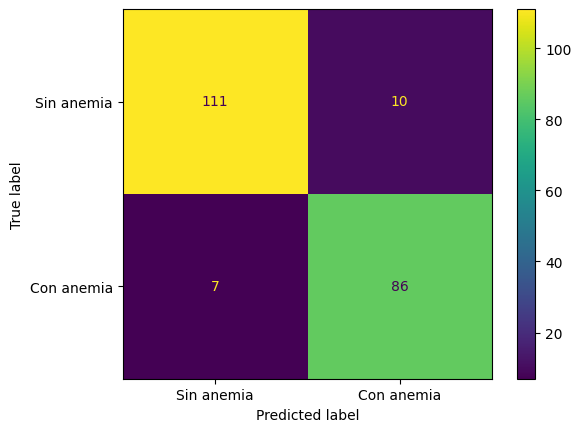

In [15]:
confusion_matrix_lr = show_confusion_matrix(y_val, y_pred_baseline)
plt.show()

### Matriz de confusión

La matriz de confusión permite analizar el desempeño del modelo más allá de las métricas agregadas, identificando los tipos de errores cometidos en la clasificación.

---

El modelo obtuvo:

* 111 verdaderos negativos, clasificando correctamente pacientes sin anemia.
* 86 verdaderos positivos, identificando correctamente pacientes con anemia.
* 10 falsos positivos, donde pacientes sin anemia fueron clasificados como positivos.
* 7 falsos negativos, donde pacientes con anemia no fueron detectados.


### 1.3 Validación cruzada

In [16]:
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(random_state=82, max_iter=1000, C=0.01))
])

In [17]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=82
)

In [18]:
scores_lr = cross_validate(
    pipeline_lr,
    X_temp,
    y_temp,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1"
    ],
    return_train_score=False
)

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instanc

In [19]:
results_baseline = pd.DataFrame(scores_lr)

results_baseline

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1
0,0.055619,0.031542,0.925620,0.885965,0.952830,0.918182
1,0.088743,0.031723,0.938017,0.959596,0.896226,0.926829
2,0.039540,0.069342,0.921162,0.864407,0.971429,0.914798
3,0.040292,0.025356,0.912863,0.868421,0.942857,0.904110
4,0.033268,0.093944,0.937759,0.932692,0.923810,0.928230


In [20]:
metrics_cv_lr = show_cv_metrics(scores_lr)
metrics_cv_lr

{'accuracy': np.float64(0.9271),
 'precision': np.float64(0.9022),
 'recall': np.float64(0.9374),
 'f1': np.float64(0.9184)}

In [21]:
scores_lr['test_f1'].mean().round(4)

np.float64(0.9184)

In [22]:
scores_lr['test_f1'].std().round(4)

np.float64(0.0088)

### Observación:

Se noto que el valor por defecto de `C` (1) en LogisticRegression() producia un modelo con un rendimiento elevado, aunque con cierta variación entre los folds de validación cruzada. Asi tambien, se noto que algunos de estos folds presentaban metricas perfectas, lo cual podria indicar que el modelo se ajustaba bastante a las caracteristicas específicas de ciertos conjuntos de datos.

Para analizar el efecto de la regularización, se evaluaron distintos valores del hiperparámetro `C`. Al reducir este valor, se incrementó la penalización aplicada a los coeficientes del modelo, reduciendo su complejidad y logrando una mayor estabilidad entre los folds.

El valor `C=0.01` presentó un mejor equilibrio entre capacidad predictiva y generalización, manteniendo valores altos de recall y F1-score, pero reduciendo la variabilidad observada con el valor inicial.

Valores menores como `C=0.001` aumentaron demasiado la regularización, provocando una disminución significativa del recall, indicando que el modelo comenzó a perder capacidad para identificar correctamente los casos positivos.

## 2. DecisionTree

In [23]:
tree_model = DecisionTreeClassifier(random_state=82, max_depth=2, min_samples_leaf=3, min_samples_split=5)

In [24]:
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2, min_samples_leaf=3, min_samples_split=5,
                       random_state=82)

### 2.1 Evaluación de metricas

In [25]:
y_pred_tree = tree_model.predict(X_val)

In [26]:
metrics_tree = show_metrics('decision tree', y_val, y_pred_tree)
metrics_tree

"decision tree metrics: {'accuracy': 0.87, 'precision': 0.77, 'recall': 1.0, 'f1-score': 0.87}"

La evaluación del modelo de árbol de decisión realizada sobre el conjunto de validación retorno las siguientes métricas:

---

| Métrica   | Valor   | Interpretación       |
|---------- |------   |--------------|
| Accuracy  | 0.87    | El modelo clasifico correctamente el 87% de las muestras.       |
| Precision | 0.77    | De todas las predicciones positivas, el 77% corresponden realmente a casos positivos. |
| Recall    | 1.00    | El modelo clasifico correctamente el 100% de casos positivos del conjunto de datos.       |
| F1-Score  | 0.87    | El balance entre precisión y recall fue de un 87%, indicando un buen desempeño general considerando ambas métricas.       |


---

#### **Análisis**

El modelo presenta un recall perfecto (100%). Esto indica que el modelo identifico todos los casos positivos dentro del conjunto de validación. En un problema como el nuestro, donde la predicción de casos positivos es fundamental, este comportamiento es muy favorable.

Sin embargo, la precisión obtenida (77%) indica la existencia de falsos positivos, es decir, algunas muestras fueron clasificadas como positivas cuando pertenecen a la clase negativa.

Esto indica que el modelo tiende a favorecer la clase positiva. Posiblemente pueda deberse a multiples factores, como la distribución de las clases, la complejidad del modelo o los parametros utilizados.

### 2.2 Matriz de confusión

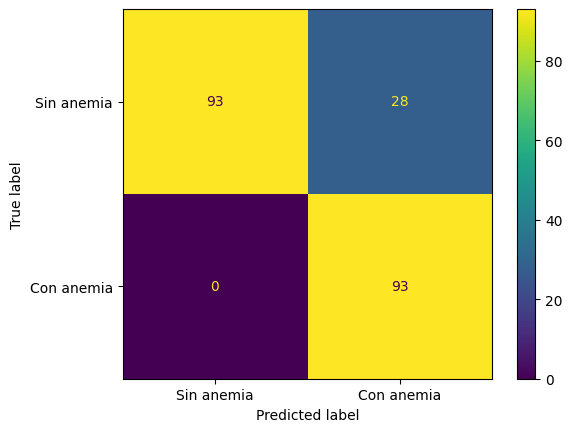

In [27]:
confusion_matrix_tree = show_confusion_matrix(y_val, y_pred_tree)
plt.show()

El modelo clasificó correctamente:

* 93 casos de pacientes sin anemia.
* 93 casos de pacientes con anemia.

---

No se observaron falsos negativos (FN = 0), lo que indica que el modelo no omitió ningún caso positivo de anemia dentro del conjunto de validación. Esto coincide con el valor de recall = 1.00, indicando una capacidad perfecta para detectar la clase positiva.

Sin embargo, se identificaron **28** falsos positivos, donde pacientes sin anemia fueron clasificados como casos positivos. Este comportamiento explica la reducción en la métrica de precisión (precision = 0.77), ya que una proporción de las predicciones positivas realizadas por el modelo fueron incorrectas.

En el contexto del problema, el modelo prioriza la detección de casos de anemia sobre evitar falsas alarmas. Esto puede ser favorable si el objetivo principal es minimizar casos no detectados, aunque implica realizar evaluaciones adicionales sobre pacientes que podrían no presentar anemia.

### 2.3 Validación cruzada

In [28]:
pipeline_tree = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=82, max_depth=2, min_samples_leaf=3, min_samples_split=5))
])

In [29]:
scores_tree = cross_validate(
    pipeline_tree,
    X_temp,
    y_temp,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1"
    ],
    return_train_score=False
)

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instanc

In [30]:
results_tree = pd.DataFrame(scores_tree)
results_tree

,fit_time,score_time,test_accuracy,test_precision,test_recall,test_f1
0,0.020461,0.038642,0.880165,0.785185,1.000000,0.879668
1,0.020557,0.035922,0.917355,0.841270,1.000000,0.913793
2,0.020285,0.038246,0.892116,0.801527,1.000000,0.889831
3,0.080701,0.099976,0.887967,0.819672,0.952381,0.881057
4,0.029400,0.030793,0.887967,0.795455,1.000000,0.886076


In [31]:
metrics_cv_tree = show_cv_metrics(scores_tree)
metrics_cv_tree

{'accuracy': np.float64(0.8931),
 'precision': np.float64(0.8086),
 'recall': np.float64(0.9905),
 'f1': np.float64(0.8901)}

In [32]:
scores_tree['test_f1'].std().round(4)

np.float64(0.0124)

### 2.4 Optimización de hiperparametros